# Exploratory Data Analysis - Dados de previsão do Cerrado Mineiro 



In [1]:
# importing libraries

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt



In [2]:
df = pd.read_parquet("/home/avelaralencar/Desktop/zettaLab/Desafio-3_Zetta/bdqueimadas_final.parquet")

df.head()

,DataHora,Satelite,Pais,Estado,Municipio,Bioma,DiaSemChuva,Precipitacao,RiscoFogo,FRP,Latitude,Longitude,Temperatura_C,Umidade_Relativa_%,Vento_ms
0,2006-01-01 19:36:31,NOAA-12,Brasil,MINAS GERAIS,DOM JOAQUIM,Mata Atlântica,2.880902,1.891633,0.232410,13.28259,-18.97500,-43.17833,28.155182,64.171715,2.171288
1,2006-01-02 13:12:00,TERRA_M-T,Brasil,MINAS GERAIS,CAPITÃO ENÉAS,Cerrado,4.505004,0.692786,0.551207,9.10000,-15.93700,-43.57200,25.657135,66.851326,2.544036
2,2006-01-04 10:30:00,GOES-12,Brasil,MINAS GERAIS,PEDRAS DE MARIA DA CRUZ,Cerrado,9.432938,0.491288,0.851968,29.90662,-15.82924,-44.56667,25.866364,62.102680,2.779779
3,2006-01-04 13:00:00,TERRA_M-T,Brasil,MINAS GERAIS,PONTO DOS VOLANTES,Mata Atlântica,13.436250,0.375919,0.845394,13.20000,-16.87100,-41.51900,24.646149,63.498455,2.402524
4,2006-01-04 15:45:00,AQUA_M-T,Brasil,MINAS GERAIS,ÁGUAS VERMELHAS,Mata Atlântica,6.869480,0.251495,0.756708,44.60000,-15.72600,-41.53400,30.042145,40.695217,2.253159


In [3]:
# Explorando a estrutura dos dados
print("Forma do dataset:", df.shape)
print("\nColunas disponíveis:")
print(df.columns.tolist())
print("\nTipos de dados:")
print(df.dtypes)
print("\nPrimeiras informações:")
df.info()

Forma do dataset: (2163477, 15)

Colunas disponíveis:
['DataHora', 'Satelite', 'Pais', 'Estado', 'Municipio', 'Bioma', 'DiaSemChuva', 'Precipitacao', 'RiscoFogo', 'FRP', 'Latitude', 'Longitude', 'Temperatura_C', 'Umidade_Relativa_%', 'Vento_ms']

Tipos de dados:
DataHora              datetime64[ns]
Satelite                      object
Pais                          object
Estado                        object
Municipio                     object
Bioma                         object
DiaSemChuva                  float64
Precipitacao                 float64
RiscoFogo                    float64
FRP                          float64
Latitude                     float64
Longitude                    float64
Temperatura_C                float64
Umidade_Relativa_%           float64
Vento_ms                     float64
dtype: object

Primeiras informações:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2163477 entries, 0 to 2163476
Data columns (total 15 columns):
 #   Column              Dtype 

In [4]:
# Quantidade de dados para cada estado
print("=" * 50)
print("QUANTIDADE DE DADOS POR ESTADO")
print("=" * 50)
dados_por_estado = df['Estado'].value_counts().sort_values(ascending=False)
print(dados_por_estado)
print(f"\nTotal de registros: {len(df)}")
print(f"Total de estados: {df['Estado'].nunique()}")

QUANTIDADE DE DADOS POR ESTADO
Estado
MINAS GERAIS    2163477
Name: count, dtype: int64

Total de registros: 2163477
Total de estados: 1


In [5]:
# Verificar quais biomas temos no dataset
print("\nBiomas disponíveis no dataset:")
print(df['Bioma'].value_counts())



Biomas disponíveis no dataset:
Bioma
Cerrado           1310222
Mata Atlântica     799435
Caatinga            53820
Name: count, dtype: int64


In [6]:
# Criando dataframe apenas com dados do Cerrado
df_cerrado = df[df['Bioma'] == 'Cerrado'].copy()

print("=" * 50)
print("DADOS DO CERRADO EM MINAS GERAIS")
print("=" * 50)
print(f"\nTotal de registros do Cerrado: {len(df_cerrado)}")
print(f"Percentual do dataset total: {(len(df_cerrado)/len(df)*100):.2f}%")
print(f"\nEstados com registros do Cerrado:")
print(df_cerrado['Estado'].value_counts())
print(f"\nForma do dataframe: {df_cerrado.shape}")

# Análise inicial do Cerrado
print("=" * 50)
print("ANÁLISE INICIAL - CERRADO")
print("=" * 50)
print("\nInformações básicas do Cerrado:")
print(df_cerrado.describe())
print("\nValores nulos por coluna:")
print(df_cerrado.isnull().sum())
print("\nTipos de dados:")
print(df_cerrado.dtypes)

DADOS DO CERRADO EM MINAS GERAIS

Total de registros do Cerrado: 1310222
Percentual do dataset total: 60.56%

Estados com registros do Cerrado:
Estado
MINAS GERAIS    1310222
Name: count, dtype: int64

Forma do dataframe: (1310222, 15)
ANÁLISE INICIAL - CERRADO

Informações básicas do Cerrado:
                            DataHora   DiaSemChuva  Precipitacao  \
count                        1310222  1.310222e+06  1.310222e+06   
mean   2019-05-27 00:24:46.797770496  3.176171e+01  3.598839e-01   
min              2006-01-02 13:12:00  0.000000e+00  0.000000e+00   
25%              2015-09-25 16:43:00  5.000000e+00  0.000000e+00   
50%              2020-09-20 16:18:00  1.500000e+01  0.000000e+00   
75%              2023-08-24 04:17:00  4.933804e+01  5.609280e-02   
max              2026-03-31 05:01:00  8.360000e+02  9.200000e+01   
std                              NaN  3.674962e+01  1.991195e+00   

          RiscoFogo           FRP      Latitude     Longitude  Temperatura_C  \
count  1.310

In [7]:
# Análise inicial do Cerrado
print("=" * 50)
print("ANÁLISE INICIAL - CERRADO")
print("=" * 50)
print("\nInformações básicas do Cerrado:")
print(df_cerrado.describe())
print("\nValores nulos por coluna:")
print(df_cerrado.isnull().sum())
print("\nTipos de dados:")
print(df_cerrado.dtypes)

ANÁLISE INICIAL - CERRADO

Informações básicas do Cerrado:
                            DataHora   DiaSemChuva  Precipitacao  \
count                        1310222  1.310222e+06  1.310222e+06   
mean   2019-05-27 00:24:46.797770496  3.176171e+01  3.598839e-01   
min              2006-01-02 13:12:00  0.000000e+00  0.000000e+00   
25%              2015-09-25 16:43:00  5.000000e+00  0.000000e+00   
50%              2020-09-20 16:18:00  1.500000e+01  0.000000e+00   
75%              2023-08-24 04:17:00  4.933804e+01  5.609280e-02   
max              2026-03-31 05:01:00  8.360000e+02  9.200000e+01   
std                              NaN  3.674962e+01  1.991195e+00   

          RiscoFogo           FRP      Latitude     Longitude  Temperatura_C  \
count  1.310222e+06  1.310222e+06  1.310222e+06  1.310222e+06   1.310222e+06   
mean   9.143049e-01  2.888556e+01 -1.795371e+01 -4.566510e+01   2.762655e+01   
min    0.000000e+00  0.000000e+00 -2.161404e+01 -5.087214e+01   2.795563e+00   
25%    9

Temperatura_C         0
Umidade_Relativa_%    0
Vento_ms              0
FRP                   0
RiscoFogo             0
dtype: int64


array([[<Axes: title={'center': 'Temperatura_C'}>,
        <Axes: title={'center': 'Umidade_Relativa_%'}>],
       [<Axes: title={'center': 'Vento_ms'}>, <Axes: >]], dtype=object)

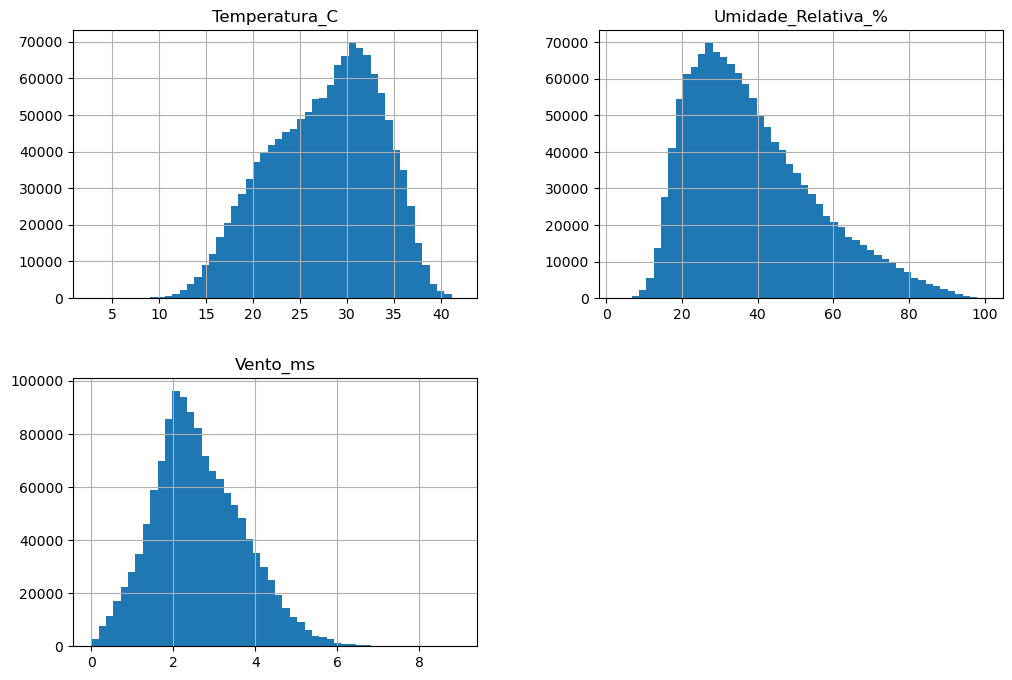

In [8]:
# Verificando dados nulos em variáveis críticas
print(df_cerrado[['Temperatura_C', 'Umidade_Relativa_%', 'Vento_ms', 'FRP', 'RiscoFogo']].isnull().sum())

# Entendendo a distribuição e buscando outliers (ex: Umidade negativa ou > 100%, Temperaturas irreais)
df_cerrado[['Temperatura_C', 'Umidade_Relativa_%', 'Vento_ms']].hist(bins=50, figsize=(12, 8))

/tmp/ipykernel_86421/56727571.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cerrado, x='Mes', palette='YlOrRd')


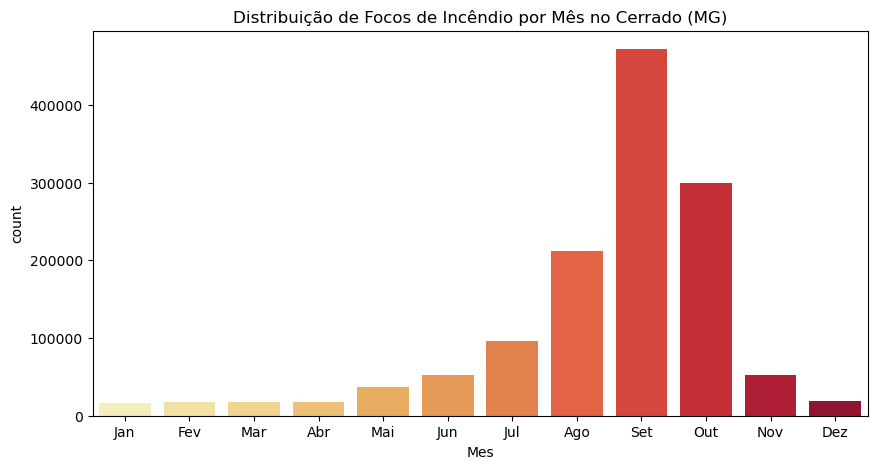

In [9]:
# Extraindo componentes temporais

meses = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr',
    5: 'Mai', 6: 'Jun', 7: 'Jul', 8: 'Ago',
    9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}

df_cerrado['Mes'] = df_cerrado['DataHora'].dt.month.map(meses)
df_cerrado['Ano'] = df_cerrado['DataHora'].dt.year
df_cerrado['DiaDoAno'] = df_cerrado['DataHora'].dt.dayofyear
df_cerrado['Hora'] = df_cerrado['DataHora'].dt.hour

# Visualizando a sazonalidade (Focos de incêndio por mês)

import seaborn as sns   

plt.figure(figsize=(10, 5))
sns.countplot(data=df_cerrado, x='Mes', palette='YlOrRd')
plt.title('Distribuição de Focos de Incêndio por Mês no Cerrado (MG)')
plt.show()

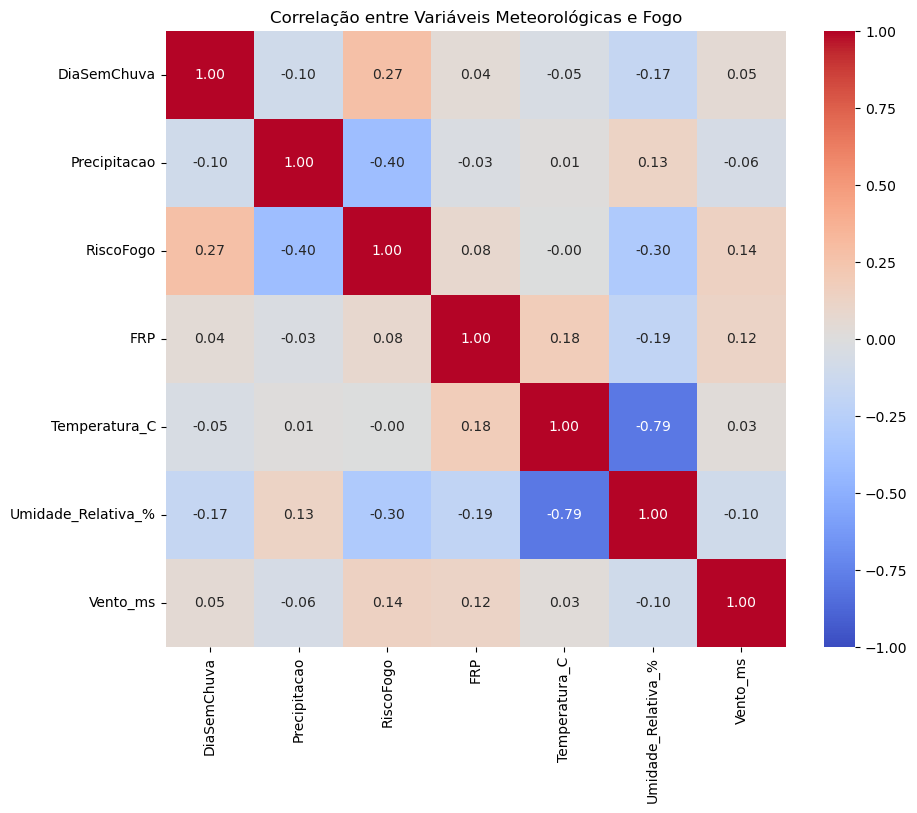

In [10]:
# Selecionando apenas variáveis numéricas relevantes
cols_numericas = ['DiaSemChuva', 'Precipitacao', 'RiscoFogo', 'FRP', 
                  'Temperatura_C', 'Umidade_Relativa_%', 'Vento_ms']

plt.figure(figsize=(10, 8))
matriz_corr = df_cerrado[cols_numericas].corr()
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlação entre Variáveis Meteorológicas e Fogo')
plt.show()

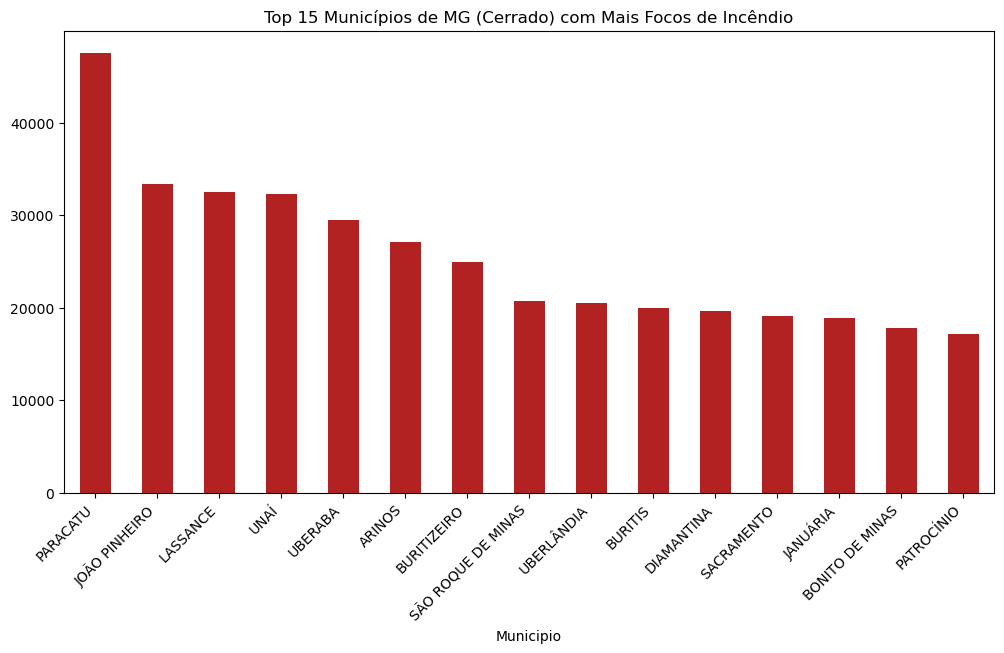

In [11]:
# Top 15 municípios com mais focos
top_municipios = df_cerrado['Municipio'].value_counts().head(15)

plt.figure(figsize=(12, 6))
top_municipios.plot(kind='bar', color='firebrick')
plt.title('Top 15 Municípios de MG (Cerrado) com Mais Focos de Incêndio')
plt.xticks(rotation=45, ha='right')
plt.show()

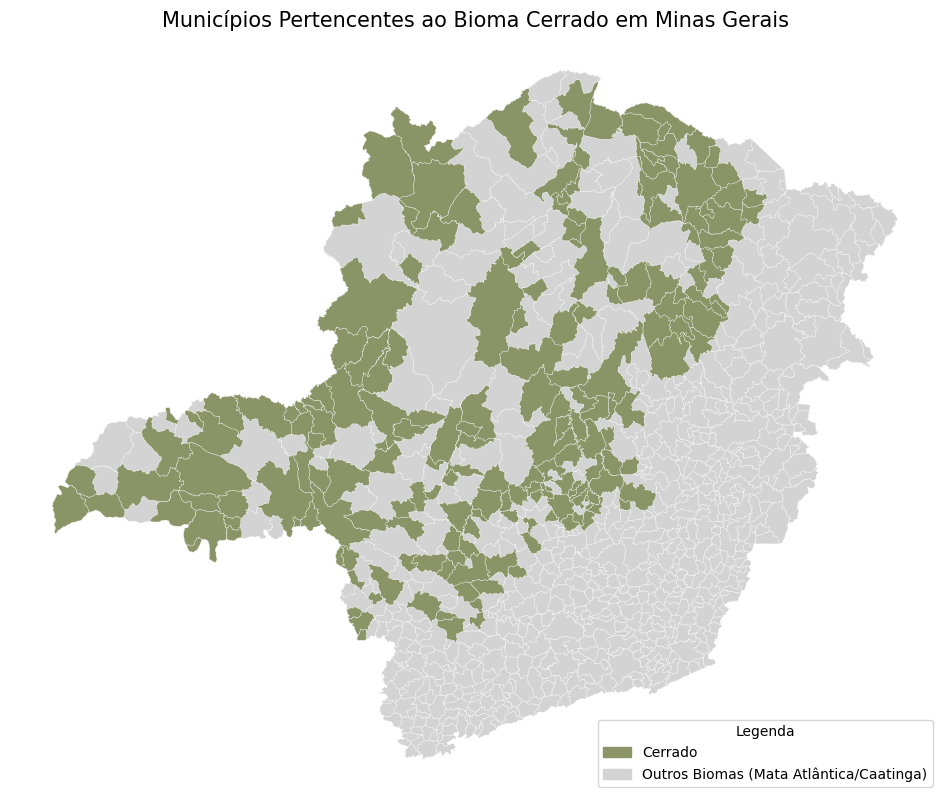

In [12]:
# Mapa das cidades pertencentes ao cerrado mineiro 

import geopandas as gpd
import matplotlib.pyplot as plt
from geobr import read_municipality

# 1. Obter a lista de cidades únicas que pertencem ao Cerrado no seu dataset
# (Garantindo que os nomes já passaram pelo tratamento de acentos e maiúsculas)
cidades_cerrado = df_cerrado['Municipio'].unique()

# 2. Baixar a malha de municípios de Minas Gerais
mg_shape = read_municipality(code_muni="MG", year=2020)

# 3. Padronizar o shapefile do IBGE (Maiúsculas e sem acentos)
mg_shape['name_muni_clean'] = (
    mg_shape['name_muni']
    .str.upper()
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
)

# 4. Criar uma coluna booleana: 'Sim' se a cidade está no seu dataset de Cerrado, 'Não' caso contrário
mg_shape['Pertence_ao_Cerrado'] = mg_shape['name_muni_clean'].isin(cidades_cerrado)
mg_shape['Legenda'] = mg_shape['Pertence_ao_Cerrado'].map({True: 'Cerrado', False: 'Outros Biomas'})

# 5. Plotar o mapa
fig, ax = plt.subplots(figsize=(12, 10))

# Plotando as cidades que NÃO são Cerrado em cinza claro
mg_shape[mg_shape['Pertence_ao_Cerrado'] == False].plot(
    ax=ax, color='lightgrey', edgecolor='white', linewidth=0.2
)

# Plotando as cidades do Cerrado em uma cor de destaque (ex: Verde Oliva ou Laranja)
mg_shape[mg_shape['Pertence_ao_Cerrado'] == True].plot(
    ax=ax, color='#8B9467', edgecolor='white', linewidth=0.2, label='Cerrado Mineiro'
)

# Ajustes estéticos
ax.set_title('Municípios Pertencentes ao Bioma Cerrado em Minas Gerais', fontsize=15)
ax.axis('off')

# Criando uma legenda manual simples
import matplotlib.patches as mpatches
cerrado_patch = mpatches.Patch(color='#8B9467', label='Cerrado')
outros_patch = mpatches.Patch(color='lightgrey', label='Outros Biomas (Mata Atlântica/Caatinga)')
plt.legend(handles=[cerrado_patch, outros_patch], loc='lower right', title="Legenda")

plt.show()

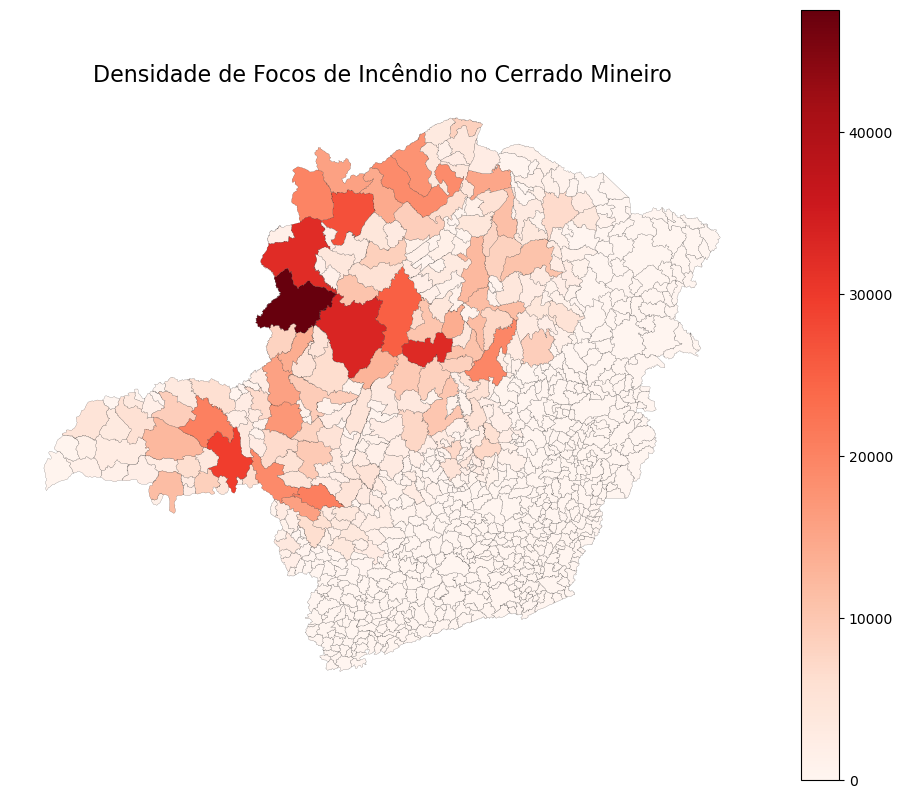

In [13]:

import geopandas as gpd
import matplotlib.pyplot as plt
from geobr import read_municipality

# 1. Tratando o seu dataset (df_cerrado)
# Garantindo que está tudo maiúsculo e removendo acentos
df_cerrado['Municipio'] = (
    df_cerrado['Municipio']
    .str.upper()
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
)

# 2. Agrupar os dados do seu dataset: Contar focos por município
focos_por_municipio = df_cerrado.groupby('Municipio').size().reset_index(name='Total_Focos')

# 3. Baixar a malha de municípios de Minas Gerais via IBGE (geobr)
# Importante: O download precisa acontecer ANTES de tentarmos tratar as colunas dele
mg_shape = read_municipality(code_muni="MG", year=2020)

# 4. Tratando o dataset do IBGE (mg_shape)
# Garantindo que está tudo maiúsculo e removendo acentos da coluna 'name_muni' para o match perfeito
mg_shape['name_muni'] = (
    mg_shape['name_muni']
    .str.upper()
    .str.normalize('NFKD')
    .str.encode('ascii', errors='ignore')
    .str.decode('utf-8')
)

# 5. Fazer o merge (join) do shapefile espacial com os seus dados de contagem
mapa_dados = mg_shape.merge(focos_por_municipio, left_on='name_muni', right_on='Municipio', how='left')

# Preencher municípios sem focos registrados com 0 para não ficarem "buracos" no mapa
mapa_dados['Total_Focos'] = mapa_dados['Total_Focos'].fillna(0)

# 6. Plotar o mapa de calor (Choropleth map)
fig, ax = plt.subplots(figsize=(12, 10))

mapa_dados.plot(
    column='Total_Focos',
    cmap='Reds',          # Paleta de cores (vermelho para fogo)
    linewidth=0.1,        # Espessura da linha da fronteira
    edgecolor='black',    # Cor da fronteira
    legend=True,          # Mostra a barra de cores
    ax=ax,
    missing_kwds={'color': 'lightgrey'} # Cor para cidades sem dados (se houver)
)

ax.set_title('Densidade de Focos de Incêndio no Cerrado Mineiro', fontsize=16)
ax.axis('off') # Esconde os eixos de latitude/longitude para ficar mais limpo
plt.show()